# Tema 3. ADL en el hospital: comprender las predicciones y sus errores

**Versión 2026-10-03-v1 · Médicos y enfermeras · CPU · Sin programar.**

🧭 **Orientarse.** Este cuaderno acompaña exclusivamente al **PDF alternativo del Tema 3, edición 03/10/2026, con cambios en azul**. Conserva ambos archivos juntos. Las referencias usan apartados, no páginas: no utilices el antiguo PDF rotulado Tema 2. El manual se distribuye por separado y no hace falta publicarlo en GitHub para ejecutar este cuaderno.

**Pregunta principal:** ¿cómo clasifica un ADL muestras de Wisconsin como benignas o malignas, y qué errores comete en muestras reservadas? La clase positiva será **malignidad**, aunque su código original sea 0. El caso secundario de disnea es una **simulación nueva**, no un estudio clínico.

**Al terminar podrás:** identificar datos y evento, distinguir entrenamiento de evaluación, leer una tabla de errores, interpretar sensibilidad y especificidad con incertidumbre y redactar una conclusión prudente. No necesitas recordar fórmulas ni escribir Python.

**Tiempo orientativo:** dos sesiones de 60-75 minutos para B01-B10 y B14-B16. B11-B13 son ampliaciones, unos 30 minutos: puedes ejecutar sus celdas sin estudiar el código para obtener todos los recursos. Todas las celdas se pueden ejecutar en orden.

**Leyenda:** 🧭 Orientarse · 🎯 Pregunta · ▶ Ejecutar · 👀 Interpretar · 📝 Responder · 💬 Pedir ayuda · 🌱 Ampliar.

## Tu primera sesión en Colab

1. Google Colab permite abrir y ejecutar un **notebook**, un documento con explicaciones y cálculos, en el navegador. Abre https://colab.research.google.com/ y usa **Archivo → Subir cuaderno** para abrir el archivo de esta entrega. Tras su publicación también podrás buscarlo en la pestaña GitHub. No uses un enlace a los cuadernos antiguos.
2. Elige **Archivo → Guardar una copia en Drive**. Trabaja en tu copia y conserva el nombre de la versión. No necesitas GPU ni una cuenta de pago.
3. Una **celda de texto** contiene explicaciones. Una **celda de código** contiene instrucciones preparadas para el ordenador. **Ejecutar** significa pulsar el triángulo a su izquierda; también puedes usar Mayús+Intro.
4. Prueba la primera celda de abajo. Si aparece el mensaje, ya sabes ejecutar. Después continúa de arriba abajo. **Entorno de ejecución → Ejecutar todas** sirve para comprobar el cuaderno completo, pero recuerda parar a interpretar.
5. Para responder, haz doble clic en la celda **Tu respuesta**, escribe debajo del enunciado y pulsa Mayús+Intro. No cambies las celdas de cálculo.
6. Si falla un bloque, vuelve a ejecutar desde el inicio. Si persiste, reinicia la sesión desde **Entorno de ejecución** y ejecuta todas. Comunica al docente el identificador B01, B02, etc. y el mensaje visible. No necesitas interpretar el código del error.
7. Al terminar, guarda la copia y usa **Archivo → Descargar → Descargar .ipynb** para entregar tus respuestas. Las descargas de figuras se explican en B16.

**Disponibilidad:** los datos reales vienen incluidos con scikit-learn. La preparación solo descarga paquetes si faltan; requiere conexión en ese caso. No se descargan historias clínicas ni se usan rutas privadas.


In [1]:
print('Ya sabes ejecutar una celda. Continúa con la preparación y guarda tu copia.')

Ya sabes ejecutar una celda. Continúa con la preparación y guarda tu copia.


In [2]:
#@title Preparar el entorno automáticamente
import importlib.util, subprocess, sys
necesarios = {'numpy':'numpy>=1.24', 'pandas':'pandas>=1.5', 'scipy':'scipy>=1.10',
              'sklearn':'scikit-learn>=1.3', 'matplotlib':'matplotlib>=3.7', 'jinja2':'jinja2>=3.1'}
faltan = [paquete for modulo,paquete in necesarios.items() if importlib.util.find_spec(modulo) is None]
if faltan:
    try:
        subprocess.check_call([sys.executable,'-m','pip','install','-q',*faltan])
    except Exception as exc:
        raise RuntimeError('La preparación no ha terminado. Reinicia la sesión, ejecuta desde el inicio y, si persiste, comunica al docente el bloque de preparación.') from exc
print('Entorno preparado. Continúa con las herramientas del cuaderno y el bloque B01.')


Entorno preparado. Continúa con las herramientas del cuaderno y el bloque B01.


In [3]:
#@title Herramientas preparadas: ejecutar una vez, no editar
"""Código que se incorpora íntegramente al notebook autónomo. Sin rutas privadas."""
from pathlib import Path
import json, hashlib, zipfile, importlib.metadata as metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy import stats, linalg
from sklearn.datasets import load_breast_cancer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from IPython.display import display, Markdown

SALIDA = Path('recursos_adl_v1')
for carpeta in ['datos', 'tablas', 'figuras']:
    (SALIDA / carpeta).mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'font.size': 15, 'axes.spines.top': False, 'axes.spines.right': False})
AZUL, NARANJA, VERDE = '#0066A1', '#C45B00', '#00805A'
VERSION = '2026-10-03-v1'
REGISTRO = {}
RESULTADOS = {}

def huella(datos):
    return hashlib.sha256(datos).hexdigest()

def registrar(archivo, bloque, caso, metodo, unidades='sin unidad', n=None):
    REGISTRO[str(archivo.relative_to(SALIDA))] = {
        'bloque': bloque, 'caso': caso, 'metodo': metodo, 'unidades': unidades,
        'n': n, 'version': VERSION, 'sha256': huella(archivo.read_bytes()),
        'estado': 'generado en la ejecución del notebook; validación al cerrar B16'}

def tabla(nombre, df, bloque, caso, metodo, unidades='ver encabezados', n=None, mostrar=True):
    destino = SALIDA / 'tablas' / nombre
    df.to_csv(destino.with_suffix('.csv'), index=False, encoding='utf-8', lineterminator='\n')
    destino.with_suffix('.tex').write_text(df.to_latex(index=False, escape=True,
        float_format=lambda x: f'{x:.4g}' if 0 < abs(x) < .001 else f'{x:.3f}'), encoding='utf-8')
    for ext in ['.csv', '.tex']:
        registrar(destino.with_suffix(ext), bloque, caso, metodo, unidades, n)
    if mostrar:
        display(df)
    return df

def figura(nombre, fig, bloque, caso, metodo, unidades='ver ejes', n=None):
    for ext in ['pdf', 'png']:
        archivo = SALIDA / 'figuras' / f'{nombre}.{ext}'
        fig.savefig(archivo, dpi=180, bbox_inches='tight')
        registrar(archivo, bloque, caso, metodo, unidades, n)
    plt.show()
    plt.close(fig)

def texto(frase):
    display(Markdown(frase))

def wilson(k, n):
    z = stats.norm.ppf(.975); p = k / n
    centro = (p + z*z/(2*n))/(1 + z*z/n)
    margen = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n))/(1 + z*z/n)
    return float(centro-margen), float(centro+margen)

def matriz_fig(cm, nombres, titulo):
    fig, ax = plt.subplots(figsize=(6.3, 4.6), layout='constrained')
    nombres = [n.replace('Insuf. cardiaca', 'Insuf.\ncardiaca') for n in nombres]
    titulo = titulo.replace('SIMULACIÓN: evaluación en 27 ingresos reservados',
                            'SIMULACIÓN: evaluación\nen 27 ingresos reservados')
    ax.imshow(cm, cmap='Blues', vmin=0)
    for i in range(len(nombres)):
        for j in range(len(nombres)):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=19,
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
    ax.set(xticks=range(len(nombres)), xticklabels=nombres,
           yticks=range(len(nombres)), yticklabels=nombres,
           xlabel='Clasificación del modelo', ylabel='Clasificación de referencia', title=titulo)
    return fig

def B01():
    global X, y, ids, nombres, diccionario
    datos = load_breast_cancer()
    X = datos.data.copy(); y = datos.target.copy(); nombres = datos.feature_names
    ids = np.arange(len(y))
    assert X.shape == (569,30) and np.isfinite(X).all()
    assert list(datos.target_names) == ['malignant','benign']
    assert np.bincount(y).tolist() == [212,357]
    archivo = SALIDA / 'datos' / 'wisconsin.csv'
    df = pd.DataFrame(X, columns=nombres); df.insert(0,'fila_docente',ids)
    df['diagnostico_0_maligno_1_benigno'] = y
    df.to_csv(archivo,index=False,float_format='%.12g',lineterminator='\n')
    registrar(archivo,'B01','Wisconsin','copia de load_breast_cancer; sin exclusiones',n=569)
    bases = [
        ('radius','Radio','Distancia del centro al borde del núcleo','Escala original de imagen; unidad física no documentada'),
        ('texture','Textura','Variación de los niveles de gris','Escala de gris de la imagen'),
        ('perimeter','Perímetro','Longitud del contorno del núcleo','Escala original de imagen; unidad física no documentada'),
        ('area','Área','Superficie del núcleo','Escala original de imagen; unidad física no documentada'),
        ('smoothness','Irregularidad local del radio','Variación local de las longitudes del radio','Índice de imagen; sin unidad clínica documentada'),
        ('compactness','Compacidad','Perímetro al cuadrado / área menos 1','Adimensional'),
        ('concavity','Concavidad','Intensidad de las concavidades del contorno','Índice de imagen'),
        ('concave points','Puntos cóncavos','Característica relativa a porciones cóncavas del contorno','Escala original; no atribuir unidad clínica'),
        ('symmetry','Simetría','Característica de simetría del núcleo','Índice de imagen'),
        ('fractal dimension','Dimensión fractal','Complejidad del contorno menos 1','Adimensional')]
    filas=[]
    for prefijo, sufijo, resumen in [('mean ','','Media entre núcleos'),('', ' error','Error estándar entre núcleos'),('worst ','','Media de los tres valores mayores')]:
        for en, es, significado, unidad in bases:
            filas.append([prefijo+en+sufijo,es,significado,resumen,unidad])
    diccionario=pd.DataFrame(filas,columns=['Variable original','Nombre','Qué mide','Resumen','Unidad o escala'])
    tabla('diccionario_wisconsin',diccionario,'B01','Wisconsin','diccionario de 30 características',n=569,mostrar=False)
    tabla('poblacion',pd.DataFrame({'Grupo':['Maligno','Benigno','Total'],'Muestras':[212,357,569]}),'B01','Wisconsin','recuento',n=569)
    tabla('ejemplo_filas',pd.DataFrame({'Fila docente':ids[:5]+1,'Radio medio':X[:5,0],
        'Textura media':X[:5,1],'Referencia':np.where(y[:5]==0,'Maligno','Benigno')}),'B01','Wisconsin','primeras cinco filas, no medias de grupo',n=5)
    texto('**Una fila = una muestra.** Los números del radio no son mm documentados. No hay valores ausentes; se conservan las 569 muestras. El identificador docente solo sirve para seguir las filas y nunca entra en el modelo.')
    RESULTADOS['wisconsin']={'n':569,'malignas':212,'benignas':357,'datos_sha256':huella(archivo.read_bytes())}

def B02():
    global tr, te
    tr, te = train_test_split(ids,test_size=.3,random_state=42,stratify=y)
    assert not set(tr).intersection(te) and len(tr)+len(te)==569
    resumen = pd.DataFrame([{'Uso':uso,'Malignas':int(sum(y[ind]==0)),
        'Benignas':int(sum(y[ind]==1)),'Total':len(ind)} for uso,ind in [('Entrenamiento',tr),('Test reservado',te)]])
    tabla('particion',resumen,'B02','Wisconsin','70/30 estratificado; semilla 42',n=569)
    archivo=SALIDA/'datos'/'particion.csv'
    pd.DataFrame({'fila_docente':ids,'uso':np.where(np.isin(ids,tr),'entrenamiento','test')}).to_csv(archivo,index=False)
    registrar(archivo,'B02','Wisconsin','partición fija',n=569)
    fig,ax=plt.subplots(figsize=(9,3.7),layout='constrained');ax.axis('off')
    cajas=[(.16,.67,'569 muestras\nclasificación conocida'),(.16,.18,'398 para desarrollo\ncomparación interna'),(.73,.18,'171 para evaluación\nsolo al finalizar')]
    for a,b,t in cajas:ax.text(a,b,t,ha='center',va='center',bbox=dict(boxstyle='round,pad=.7',fc='#E9F3FA',ec=AZUL))
    ax.annotate('',(.16,.34),(.16,.52),arrowprops=dict(arrowstyle='->',color=AZUL,lw=2))
    ax.annotate('',(.73,.34),(.26,.56),arrowprops=dict(arrowstyle='->',color=AZUL,lw=2))
    figura('particion',fig,'B02','Wisconsin','flujo de partición',n=569)
    RESULTADOS['wisconsin'].update(n_train=len(tr),n_test=len(te))

def B03():
    global base, pred, prob, cm, met
    base=make_pipeline(StandardScaler(),LinearDiscriminantAnalysis(solver='svd'))
    base.fit(X[tr],y[tr]); pred=base.predict(X[te])
    prob=base.predict_proba(X[te])[:,int(np.flatnonzero(base.classes_==0)[0])]
    cm=confusion_matrix(y[te],pred,labels=[0,1]);tp,fn,fp,tn=map(int,cm.ravel())
    assert cm.sum()==171
    tabla('confusion',pd.DataFrame({'Referencia':['Maligno','Benigno'],'Predice maligno':[tp,fp],
        'Predice benigno':[fn,tn],'Total':[tp+fn,fp+tn]}),'B03','Wisconsin','LDA SVD; umbral 0.5',n=171)
    figura('confusion',matriz_fig(cm,['Maligno','Benigno'],'Aciertos y errores: 171 muestras reservadas'),
           'B03','Wisconsin','matriz de confusión',n=171)
    met={'TP':tp,'FN':fn,'FP':fp,'TN':tn,'exactitud':(tp+tn)/171,
         'sensibilidad':tp/(tp+fn),'especificidad':tn/(tn+fp),'vpp':tp/(tp+fp),'vpn':tn/(tn+fn),
         'auc':float(roc_auc_score(y[te]==0,prob))}
    RESULTADOS['wisconsin'].update(met)
    texto(f'**Lee primero la fila Maligno:** {tp} identificadas y {fn} clasificadas como benignas. Estos {fn} errores son falsos negativos; no son muestras benignas.')

def B04():
    global metricas
    t=met
    pares=[('Sensibilidad',t['TP'],t['TP']+t['FN']),('Especificidad',t['TN'],t['TN']+t['FP']),
           ('VPP',t['TP'],t['TP']+t['FP']),('VPN',t['TN'],t['TN']+t['FN']),('Exactitud',t['TP']+t['TN'],len(te))]
    metricas=pd.DataFrame([{'Medida':nom,'Numerador':k,'Denominador':n,'Porcentaje':100*k/n,
        'IC95 inferior (%)':100*wilson(k,n)[0],'IC95 superior (%)':100*wilson(k,n)[1]} for nom,k,n in pares])
    tabla('metricas',metricas,'B04','Wisconsin','proporciones e IC95 de Wilson condicionados al ajuste','porcentaje',171)
    tabla('metricas_pdf',pd.DataFrame({'Medida':metricas.Medida,
        'Cálculo':[f'{k}/{n}' for _,k,n in pares], 'Resultado (%)':[f'{100*k/n:.1f}' for _,k,n in pares],
        'IC95 (%)':[f'{100*wilson(k,n)[0]:.1f} a {100*wilson(k,n)[1]:.1f}' for _,k,n in pares]}),
        'B04','Wisconsin','presentación de proporciones','porcentaje',171,False)
    seleccion=metricas.iloc[[0,1,4]]
    fig,ax=plt.subplots(figsize=(8.2,3.5),layout='constrained')
    p=seleccion.Porcentaje.to_numpy();lo=seleccion['IC95 inferior (%)'].to_numpy();hi=seleccion['IC95 superior (%)'].to_numpy()
    ax.errorbar(p,np.arange(3),xerr=[p-lo,hi-p],fmt='o',capsize=5,color=AZUL)
    ax.set(yticks=np.arange(3),yticklabels=seleccion.Medida,xlim=(65,101),xlabel='Porcentaje e IC del 95 %',title='La precisión de las estimaciones también importa')
    figura('intervalos',fig,'B04','Wisconsin','IC de Wilson','porcentaje',171)
    RESULTADOS['wisconsin']['ic_sensibilidad']=wilson(t['TP'],t['TP']+t['FN'])
    RESULTADOS['wisconsin']['ic_exactitud']=wilson(t['TP']+t['TN'],171)

def B05():
    fpr,tpr,_=roc_curve(y[te]==0,prob)
    fig,ax=plt.subplots(figsize=(6.5,4.7),layout='constrained')
    ax.plot(fpr,tpr,color=AZUL,label=f'ADL; AUC = {met["auc"]:.3f}')
    ax.plot([0,1],[0,1],'--',color='gray',label='Referencia sin discriminación')
    ax.scatter([1-met['especificidad']],[met['sensibilidad']],marker='s',s=65,color=NARANJA,label='Umbral fijado: 0,5',zorder=5)
    ax.set(xlabel='Proporción de benignas clasificadas como malignas',ylabel='Proporción de malignas identificadas',title='ROC: cambiar el umbral cambia los errores')
    ax.legend(fontsize=13);figura('roc',fig,'B05','Wisconsin','ROC; evento malignidad',n=171)
    filas=[]
    for a,b in zip(np.linspace(0,1,6)[:-1],np.linspace(0,1,6)[1:]):
        ind=(prob>=a)&((prob<=b) if b==1 else (prob<b))
        if ind.sum():filas.append({'Intervalo':f'{a:.1f}-{b:.1f}','n':int(ind.sum()),
            'Probabilidad media':float(prob[ind].mean()),'Fracción maligna':float((y[te][ind]==0).mean())})
    tabla('calibracion_exploratoria',pd.DataFrame(filas),'B05','Wisconsin','calibración descriptiva en cinco intervalos, no reajuste',n=171)
    texto('**AUC y probabilidad no son equivalentes.** La tabla de probabilidades es exploratoria: un intervalo con pocas muestras informa poco. No reajustamos el modelo ni elegimos umbrales mirando este test.')

def B06():
    global busqueda
    pipe=make_pipeline(StandardScaler(),LinearDiscriminantAnalysis())
    cv=StratifiedKFold(5,shuffle=True,random_state=42)
    grid=[{'lineardiscriminantanalysis__solver':['svd']},
          {'lineardiscriminantanalysis__solver':['eigen'],'lineardiscriminantanalysis__shrinkage':['auto',.1,.3,.5,.7,.9]}]
    busqueda=GridSearchCV(pipe,grid,scoring='balanced_accuracy',cv=cv,n_jobs=1,error_score='raise').fit(X[tr],y[tr])
    cvres=busqueda.cv_results_;filas=[]
    for p,m,s in zip(cvres['params'],cvres['mean_test_score'],cvres['std_test_score']):
        desc='Base SVD' if p['lineardiscriminantanalysis__solver']=='svd' else 'Regularización '+str(p['lineardiscriminantanalysis__shrinkage'])
        filas.append({'Configuración':desc,'Media CV (%)':100*m,'DE entre partes (%)':100*s})
    tabla('comparacion_interna',pd.DataFrame(filas),'B06','Wisconsin','cinco partes estratificadas; exactitud equilibrada','porcentaje',398)
    nuevo=busqueda.predict(X[te]);exact=float(np.mean(nuevo==y[te]))
    RESULTADOS['wisconsin'].update(mejor_cv=float(busqueda.best_score_),mejor_configuracion=busqueda.best_params_,exactitud_cv=exact,
        predicciones_iguales=bool(np.array_equal(nuevo,pred)))
    tabla('comparacion_test',pd.DataFrame({'Procedimiento':['Base fijada','Elegida dentro del entrenamiento'],
        'Aciertos':[int(sum(pred==y[te])),int(sum(nuevo==y[te]))],'Muestras':[171,171],
        'Exactitud (%)':[100*met['exactitud'],100*exact]}),'B06','Wisconsin','comparación predefinida en el mismo test','porcentaje',171)
    texto(f'**Resultado calculado:** diferencia de exactitud = {100*(exact-met["exactitud"]):+.2f} puntos porcentuales. Se conserva la partición y el criterio aunque no haya mejora.')

def B07():
    explorado=X[tr];etiquetas=y[tr]
    filas=[]
    for k,nom in [(0,'Maligno'),(1,'Benigno')]:
        for j,nombre in [(0,'Radio medio'),(1,'Textura media')]:
            a=explorado[etiquetas==k,j]
            filas.append({'Grupo':nom,'Variable':nombre,'n':len(a),'Media':a.mean(),'DE':a.std(ddof=1)})
    tabla('descriptivos_entrenamiento',pd.DataFrame(filas),'B07','Wisconsin','media y DE; solo entrenamiento','escala original de imagen',398)
    fig,axes=plt.subplots(1,2,figsize=(10,4.3),layout='constrained')
    for k,nom,col,marca in [(0,'Maligno',NARANJA,'^'),(1,'Benigno',AZUL,'o')]:
        a=explorado[etiquetas==k,0];orden=np.sort(a)
        axes[0].plot(orden,np.arange(1,len(a)+1)/len(a),label=nom,color=col,ls='-' if k==0 else '--')
        q,o=stats.probplot((a-a.mean())/a.std(ddof=1),fit=False)
        axes[1].scatter(q,o,s=15,alpha=.65,marker=marca,color=col,label=nom)
    axes[0].set(xlabel='Radio medio:\nescala original de imagen',ylabel='Fracción acumulada',title='Distribuciones\nobservadas')
    axes[1].plot([-3,3],[-3,3],ls='--',color='gray')
    axes[1].set(xlabel='Posición esperada\nbajo normalidad',ylabel='Posición observada estandarizada',title='Q-Q: diagnóstico parcial\nde una variable')
    for ax in axes:ax.legend(fontsize=14)
    figura('supuestos',fig,'B07','Wisconsin','exploración dentro de grupos; entrenamiento',n=398)
    correlacion=float(np.corrcoef(explorado[:,0],explorado[:,2])[0,1])
    tabla('redundancia',pd.DataFrame({'Variables':['Radio y perímetro medios'],'Correlación':[correlacion]}),
        'B07','Wisconsin','correlación descriptiva entrenamiento',n=398)
    RESULTADOS['wisconsin']['correlacion_radio_perimetro']=correlacion

def B08():
    global sim, SX, sy, slda, Z, Sw, Sb, autovalores, modelo_datos_sim
    rng=np.random.default_rng(20261003)
    etiquetas=['Neumonía','Insuf. cardiaca','EPOC']
    variables=['FR (resp/min)','FC (lat/min)','Temperatura (°C)','SpO2 (%)','Hb (g/dL)','Leucocitos (10^9/L)']
    medias=np.array([[24,101,38.0,93,13.2,12.5],[25,98,36.7,92,12.1,8.5],[26,96,36.9,91,14.2,9.5]])
    desv=np.array([3,10,.45,1.7,1.1,2.0]);corr=np.eye(6)
    corr[0,1]=corr[1,0]=.3;corr[2,5]=corr[5,2]=.3
    cov=desv[:,None]*corr*desv[None,:]
    SX=np.vstack([rng.multivariate_normal(mu,cov,size=30) for mu in medias]);sy=np.repeat(np.arange(3),30)
    assert np.isfinite(SX).all() and (SX[:,3]>70).all() and (SX[:,3]<100).all() and (SX[:,5]>0).all()
    sim=pd.DataFrame(SX,columns=variables);sim.insert(0,'Ingreso ficticio',np.arange(1,91));sim['Grupo']=[etiquetas[k] for k in sy]
    archivo=SALIDA/'datos'/'disnea_simulada.csv';sim.to_csv(archivo,index=False,float_format='%.12g',lineterminator='\n')
    registrar(archivo,'B08','Disnea simulada','normal multivariante por grupo; covarianza común; semilla 20261003',n=90)
    modelo_datos_sim={'semilla':20261003,'n_por_grupo':30,'variables':variables,'grupos':etiquetas,
        'medias':medias.tolist(),'desviaciones':desv.tolist(),'correlacion':corr.tolist(),
        'regla':'sin recorte, sin selección de semilla; no datos clínicos reales; sin casos mixtos',
        'momento':'medición inicial ficticia, antes de intervenciones; aire ambiente solo como simplificación docente',
        'origen_etiquetas':'asignadas por generador; representarían diagnóstico principal de referencia adjudicado, no inferido por la regla',
        'datos_sha256':huella(archivo.read_bytes())}
    tabla('simulacion_medias',pd.DataFrame(medias,columns=variables).assign(Grupo=etiquetas),
          'B08','Disnea simulada','medias poblacionales fijadas antes de generar datos',n=90,mostrar=False)
    tabla('simulacion_muestra',sim.head(6),'B08','Disnea simulada','primeras seis observaciones ficticias',n=6)
    desc=sim.groupby('Grupo')[variables].mean().reset_index()
    tabla('simulacion_descriptivos',desc,'B08','Disnea simulada','medias muestrales, 30 por grupo',n=90)
    slda=LinearDiscriminantAnalysis(n_components=2).fit(SX,sy);Z=slda.transform(SX)
    media=SX.mean(axis=0);Sw=np.zeros((6,6));Sb=np.zeros((6,6))
    for k in range(3):
        g=SX[sy==k];mu=g.mean(axis=0);Sw+=(g-mu).T@(g-mu);Sb+=len(g)*np.outer(mu-media,mu-media)
    autovalores=linalg.eigvalsh(Sb,Sw)[::-1][:2]
    RESULTADOS['simulacion']={**modelo_datos_sim,'proporciones':slda.explained_variance_ratio_.tolist(),
        'autovalores':autovalores.tolist()}
    texto('**SIMULACIÓN DOCENTE.** Los grupos y sus diferencias han sido creados para explicar el método. No demuestra que estas seis variables permitan diagnosticar la causa de una disnea. No se ha entrenado una herramienta asistencial.')

def B09():
    fig,axes=plt.subplots(1,2,figsize=(10,4.6),layout='constrained')
    props=slda.explained_variance_ratio_
    for k,(nombre,col,marca) in enumerate(zip(modelo_datos_sim['grupos'],[AZUL,NARANJA,VERDE],['o','^','s'])):
        puntos=Z[sy==k];centro=puntos.mean(axis=0)
        axes[0].scatter(*puntos.T,s=27,color=col,marker=marca,label=nombre,alpha=.8)
        axes[0].scatter(*centro,marker='*',s=190,color=col,edgecolor='black')
        val,vec=np.linalg.eigh(np.cov(puntos,rowvar=False));orden=np.argsort(val)[::-1];val=val[orden];vec=vec[:,orden]
        ang=np.degrees(np.arctan2(vec[1,0],vec[0,0]));radio=np.sqrt(stats.chi2.ppf(.95,2))
        axes[0].add_patch(Ellipse(centro,width=2*radio*np.sqrt(val[0]),height=2*radio*np.sqrt(val[1]),angle=ang,
            facecolor='none',edgecolor=col,ls=['-','--',':'][k],lw=1.5))
    axes[0].set(xlabel='LD1: sin unidad clínica',ylabel='LD2: sin unidad clínica',title='90 ingresos simulados:\najuste descriptivo')
    axes[0].legend(fontsize=14)
    axes[1].bar(['LD1','LD2'],100*props,color=[AZUL,NARANJA],hatch='/')
    for k,v in enumerate(props):axes[1].text(k,100*v+1,f'{100*v:.1f} %',ha='center')
    axes[1].set(ylim=(0,110),ylabel='Porcentaje del criterio discriminante',title='Separación repartida\nentre dos ejes')
    figura('geometria',fig,'B09','Disnea simulada','SVD completo; elipses descriptivas gaussianas aproximadas 95 %',n=90)
    tabla('proporciones',pd.DataFrame({'Eje':['LD1','LD2'],'Autovalor':autovalores,'Proporción (%)':100*props}),
        'B09','Disnea simulada','autovalores normalizados','porcentaje',90)
    centros=np.array([Z[sy==k].mean(axis=0) for k in range(3)])
    tabla('centroides',pd.DataFrame({'Grupo':modelo_datos_sim['grupos'],'LD1':centros[:,0],'LD2':centros[:,1]}),
        'B09','Disnea simulada','medias de coordenadas, no pacientes reales','sin unidad clínica',90)

def B10():
    a,b=train_test_split(np.arange(90),test_size=.3,random_state=42,stratify=sy)
    clf=make_pipeline(StandardScaler(),LinearDiscriminantAnalysis()).fit(SX[a],sy[a]);p=clf.predict(SX[b])
    c=confusion_matrix(sy[b],p,labels=[0,1,2]);nombres=modelo_datos_sim['grupos']
    tabla('simulacion_test',pd.DataFrame(c,columns=nombres).assign(Referencia=nombres),
        'B10','Disnea simulada','ajuste nuevo: 63 entrenamiento y 27 test',n=27)
    figura('simulacion_confusion',matriz_fig(c,nombres,'SIMULACIÓN: evaluación en 27 ingresos reservados'),
           'B10','Disnea simulada','matriz de confusión',n=27)
    RESULTADOS['simulacion'].update(n_train=63,n_test=27,confusion=c.tolist(),exactitud=float(np.mean(p==sy[b])))
    texto(f'**Resultado de esta simulación:** {int(np.trace(c))} de 27 aciertos. El gráfico B09 utilizó todos los datos; esta evaluación utiliza un ajuste diferente, entrenado solo con 63 ingresos ficticios.')

def B11():
    centros=np.array([SX[sy==k].mean(axis=0) for k in range(3)])
    sd=np.sqrt(np.diag(Sw)/(90-3));coef=slda.scalings_[:,:2]*sd[:,None]
    resid=SX-centros[sy];zr=Z-np.array([Z[sy==k].mean(axis=0) for k in range(3)])[sy]
    estructura=np.corrcoef(np.column_stack([resid,zr]),rowvar=False)[:6,6:]
    tabla('coeficientes',pd.DataFrame({'Variable':modelo_datos_sim['variables'],'Coef. LD1 est.':coef[:,0],
        'Estructura LD1':estructura[:,0]}),'B11','Disnea simulada','coeficientes estandarizados por DE intragrupo y correlaciones intragrupo',n=90)
    fig,axes=plt.subplots(1,2,figsize=(10,4.8),layout='constrained')
    for ax,val,tit in zip(axes,[coef[:,0],estructura[:,0]],['Pesos en la\ncombinación LD1','Relación con LD1\ndentro de grupos']):
        ax.barh(modelo_datos_sim['variables'],val,color=AZUL);ax.axvline(0,color='gray',lw=.7);ax.set_title(tit,fontsize=15)
    axes[0].set_xlabel('Coeficiente estandarizado');axes[1].set(xlabel='Correlación',xlim=(-1,1))
    figura('coeficientes',fig,'B11','Disnea simulada','pesos y estructura; no efectos causales',n=90)

def B12():
    # Ejercicio ANOVA sobre una variable de la simulación: no selecciona predictores.
    j=2;grupos=[SX[sy==k,j] for k in range(3)];f,p=stats.f_oneway(*grupos)
    fig,ax=plt.subplots(figsize=(8,4.3),layout='constrained')
    dominio=np.linspace(34.5,40,350)
    for k,(col,ls) in enumerate(zip([AZUL,NARANJA,VERDE],['-','--',':'])):
        ax.plot(dominio,stats.norm.pdf(dominio,modelo_datos_sim['medias'][k][j],modelo_datos_sim['desviaciones'][j]),
                color=col,ls=ls,lw=2,label=modelo_datos_sim['grupos'][k])
    ax.set(xlabel='Temperatura inicial simulada (°C)',ylabel='Densidad (área total de cada curva = 1)',
           title='Curvas teóricas del generador:\nlas medias difieren y hay solapamiento');ax.legend(fontsize=13)
    figura('anova_solapamiento',fig,'B12','Disnea simulada','curvas normales del generador, no ajuste de datos reales','°C',90)
    tabla('anova',pd.DataFrame({'Variable':['Temperatura (°C)'],'F':[f],'p':[p],'n':[90]}),
          'B12','Disnea simulada','ANOVA exploratorio de una variable predefinida',n=90)
    total=(SX-SX.mean(axis=0)).T@(SX-SX.mean(axis=0))
    np.testing.assert_allclose(Sw+Sb,total,atol=1e-8)
    np.testing.assert_allclose(Z,(SX-slda.xbar_)@slda.scalings_[:,:2],atol=1e-8)
    np.testing.assert_allclose(slda.scalings_[:,:2].T@Sw@slda.scalings_[:,:2],87*np.eye(2),atol=1e-8)
    np.testing.assert_allclose(autovalores/autovalores.sum(),slda.explained_variance_ratio_,atol=1e-8)
    tabla('identidades',pd.DataFrame({'Comprobación':['Dispersión total = dentro + entre','Proyección coherente','Normalización intragrupo','Proporciones por autovalores'],
        'Resultado':['Correcta']*4}),'B12','Disnea simulada','verificación numérica; ampliación',n=90)
    RESULTADOS['simulacion'].update(anova_F=float(f),anova_p=float(p))

def B13():
    # Contraste global ilustrativo: tamaños fijos, bajo intercambiabilidad.
    total=(SX-SX.mean(axis=0)).T@(SX-SX.mean(axis=0));logt=np.linalg.slogdet(total)[1]
    obs=np.linalg.slogdet(Sw)[1]-logt;rng=np.random.default_rng(20261003);extremos=0
    for _ in range(1999):
        yp=rng.permutation(sy);dentro=np.zeros((6,6))
        for k in range(3):
            g=SX[yp==k];dentro+=(g-g.mean(axis=0)).T@(g-g.mean(axis=0))
        extremos+=np.linalg.slogdet(dentro)[1]-logt<=obs+1e-12
    lam=float(np.exp(obs));pmc=(int(extremos)+1)/2000
    np.testing.assert_allclose(lam,np.prod(1/(1+autovalores)),atol=1e-9)
    tabla('wilks',pd.DataFrame({'Lambda':[lam],'Permutaciones':[1999],'Extremos':[int(extremos)],'p Monte Carlo':[pmc]}),
        'B13','Disnea simulada','Wilks, cola inferior, (b+1)/(B+1)',n=90)
    RESULTADOS['simulacion'].update(wilks=lam,p_mc=pmc,permutaciones=1999)

def B16():
    # Cierre: cifras, macros y manifiesto proceden de este mismo estado ejecutado.
    assert len(tr)==398 and len(te)==171 and cm.sum()==171
    assert np.trace(cm)==met['TP']+met['TN']
    assert np.isclose(metricas.loc[metricas.Medida=='Sensibilidad','Porcentaje'].iloc[0],100*met['sensibilidad'])
    assert len(sim)==90 and len(np.unique(sy))==3
    assert all((SALIDA/f).exists() and huella((SALIDA/f).read_bytes())==r['sha256'] for f,r in REGISTRO.items())
    versiones={k:metadata.version(k) for k in ['numpy','pandas','scipy','scikit-learn','matplotlib']}
    RESULTADOS['versiones']=versiones;RESULTADOS['version']=VERSION
    archivo=SALIDA/'resultados.json';archivo.write_text(json.dumps(RESULTADOS,ensure_ascii=False,indent=2,allow_nan=False),encoding='utf-8')
    registrar(archivo,'B16','Ambos casos','cifras de narración verificadas')
    w=RESULTADOS['wisconsin'];s=RESULTADOS['simulacion']
    macros={'TP':w['TP'],'FN':w['FN'],'FP':w['FP'],'TN':w['TN'],
        'Exactitud':f'{100*w["exactitud"]:.2f}','Sensibilidad':f'{100*w["sensibilidad"]:.2f}',
        'Especificidad':f'{100*w["especificidad"]:.2f}','VPP':f'{100*w["vpp"]:.2f}','VPN':f'{100*w["vpn"]:.2f}',
        'AUC':f'{w["auc"]:.4f}','CV':f'{100*w["mejor_cv"]:.2f}',
        'SensBaja':f'{100*w["ic_sensibilidad"][0]:.1f}','SensAlta':f'{100*w["ic_sensibilidad"][1]:.1f}',
        'LDuno':f'{100*s["proporciones"][0]:.2f}','LDdos':f'{100*s["proporciones"][1]:.2f}',
        'SimExactitud':f'{100*s["exactitud"]:.2f}','SimAciertos':int(np.trace(s['confusion'])),
        'Lambda':f'{s["wilks"]:.5f}','Pmc':f'{s["p_mc"]:.4f}','AnovaF':f'{s["anova_F"]:.2f}'}
    archivo=SALIDA/'valores.tex';archivo.write_text('\n'.join('\\newcommand{\\Dato'+k+'}{'+str(v)+'}' for k,v in macros.items())+'\n',encoding='utf-8')
    registrar(archivo,'B16','Ambos casos','macros automáticas para el PDF')
    contratos={
        'Wisconsin':{'fuente':'https://doi.org/10.24432/C5DW2B','licencia':'CC BY 4.0 según UCI; copia incluida con scikit-learn',
          'datos_sha256':w['datos_sha256'],'unidad_observacion':'muestra; una fila de la base pública',
          'evento':'maligno, etiqueta original 0','referencia':'benigno, etiqueta original 1','semilla_particion':42,
          'n_inicial':569,'n_final':569,'exclusiones':0,'faltantes':0,'ic':.95,'umbral':.5,
          'metodo':'StandardScaler y LDA SVD; comparación interna de siete configuraciones por exactitud equilibrada',
          'limites':'no reconstruye el análisis del artículo; no contiene validación externa ni datos longitudinales'},
        'Disnea simulada':{**modelo_datos_sim,'n_inicial':90,'n_final':90,'ic':.95,'evento':'tres grupos nominales; sin evento binario',
          'referencia':'no ordinal; sin grupo de referencia único','metodo':'LDA; geometría completa, evaluación separada 63/27',
          'licencia':'simulación docente creada para esta entrega'}}
    for r in REGISTRO.values():
        r['estado']='ejecutado y comprobado al cerrar B16'
        r['contrato']=r['caso'] if r['caso'] in contratos else 'consultar ambos contratos'
    manifiesto={'version':VERSION,'notebook':'Tema_03_ADL_Hospital_Colab.ipynb','versiones':versiones,'contratos':contratos,'recursos':REGISTRO}
    (SALIDA/'manifiesto.json').write_text(json.dumps(manifiesto,ensure_ascii=False,indent=2,allow_nan=False),encoding='utf-8')
    archivo_zip=Path('recursos_adl_v1.zip')
    with zipfile.ZipFile(archivo_zip,'w',zipfile.ZIP_DEFLATED) as z:
        for nombre in list(REGISTRO)+['manifiesto.json']:
            z.write(SALIDA/nombre,arcname=str(Path(SALIDA.name)/nombre))
    texto('**Práctica completada.** Tablas, figuras, datos y cifras del manual están guardados en recursos_adl_v1.zip. En Colab, abre el panel Archivos y descarga ese ZIP si lo necesitas. Guarda también tu copia del notebook con tus respuestas.')


## B01. Qué representa una muestra

**PDF alternativo: apartados 1.1 y 4.1.**

En una unidad de patología mamaria se estudian aspirados con aguja fina. Wisconsin contiene 569 muestras, 212 malignas y 357 benignas. Se calculan 30 características de los núcleos: diez características con tres resúmenes. Una fila no es un núcleo aislado ni una visita de seguimiento. Usamos la referencia publicada; esta práctica no audita cómo se verificó cada diagnóstico. La pregunta se refiere a clasificar muestras, no a estimar la prevalencia de cáncer en todas las mujeres atendidas.

🎯 **Antes de ejecutar:** Si una primera fila tiene cierto radio, ¿es ese número la media de todas las muestras malignas?

▶ **Ejecutar:** pulsa el triángulo de la siguiente celda. No necesitas modificarla.

In [4]:
#@title B01: obtener las salidas
B01()

,Grupo,Muestras
0,Maligno,212
1,Benigno,357
2,Total,569


,Fila docente,Radio medio,Textura media,Referencia
0,1,17.99,10.38,Maligno
1,2,20.57,17.77,Maligno
2,3,19.69,21.25,Maligno
3,4,11.42,20.38,Maligno
4,5,20.29,14.34,Maligno


**Una fila = una muestra.** Los números del radio no son mm documentados. No hay valores ausentes; se conservan las 569 muestras. El identificador docente solo sirve para seguir las filas y nunca entra en el modelo.

👀 **Dónde mirar e interpretar.** Aparecen los recuentos y cinco filas. Localiza la columna Referencia. Radio y textura están en escalas de imagen: la fuente no permite atribuirles mm ni otras unidades clínicas inventadas. Media, error estándar y worst no son tres momentos; worst es el promedio de los tres valores mayores. El diccionario completo se exporta en B16.

📝 **Tu respuesta.** Explica la unidad de observación, el evento positivo y qué información estaría disponible al aplicar el modelo a una nueva muestra.

**Escribe aquí:** ...

<details><summary>Orientación comentada: abrir después de responder</summary>

Cada fila es una muestra; las características se extraen de su imagen. Malignidad es el evento positivo. La referencia se conoce para aprender y evaluar, pero no se aporta al modelo como predictor. Un valor de una fila no es el promedio del grupo.

</details>

## B02. Reservar muestras para evaluar

**PDF alternativo: apartados 2.1 y 5.2.**

Construimos la regla con unas muestras y comprobamos sus errores en otras. La partición es 70/30 y mantiene aproximadamente la proporción de diagnósticos. La semilla 42 permite repetir la misma partición; no se cambia para buscar un resultado mejor. El test queda reservado antes de estimar transformaciones o seleccionar configuraciones.

🎯 **Antes de ejecutar:** ¿Sería convincente evaluar una regla solo con las mismas muestras usadas para construirla?

▶ **Ejecutar:** pulsa el triángulo de la siguiente celda. No necesitas modificarla.

,Uso,Malignas,Benignas,Total
0,Entrenamiento,148,250,398
1,Test reservado,64,107,171


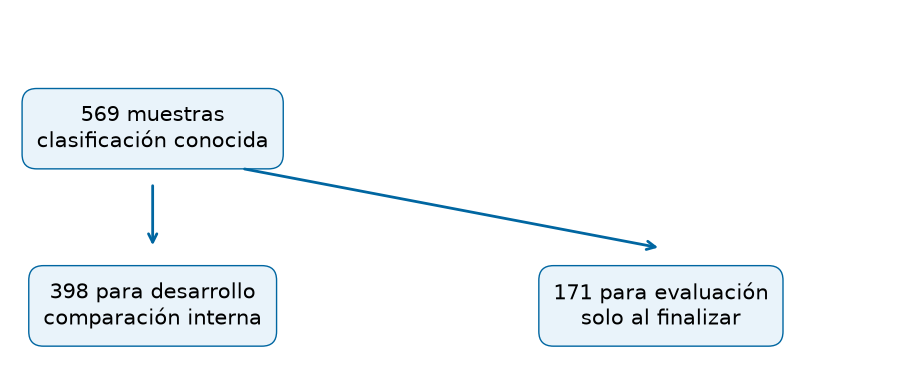

In [5]:
#@title B02: obtener las salidas
B02()

👀 **Dónde mirar e interpretar.** La tabla indica cuántas muestras de cada grupo quedan en entrenamiento y test. El esquema muestra dos usos distintos de los datos. La estratificación conserva proporciones aproximadas; no garantiza representatividad ni independencia.

📝 **Tu respuesta.** Anota cuántas muestras se reservan y explica qué ocurriría si datos repetidos de una misma persona apareciesen a ambos lados.

**Escribe aquí:** ...

<details><summary>Orientación comentada: abrir después de responder</summary>

Se reservan 171 muestras y se desarrollan los modelos con 398. Repeticiones de una persona a ambos lados podrían facilitar predicciones demasiado optimistas. En datos de visitas habría que separar por persona, no por fila.

</details>

## B03. Leer aciertos y errores

**PDF alternativo: apartados 2.2.**

El ADL combina las 30 características utilizando solo el entrenamiento. Las medias y escalas se calculan ahí y después se aplican sin reajustarlas al test. El modelo base queda fijado antes de ver este test. Positivo significa malignidad; no significa que el código numérico sea 1.

🎯 **Antes de ejecutar:** ¿Qué clasificación errónea corresponde a una muestra maligna que el modelo llama benigna?

▶ **Ejecutar:** pulsa el triángulo de la siguiente celda. No necesitas modificarla.

,Referencia,Predice maligno,Predice benigno,Total
0,Maligno,54,10,64
1,Benigno,1,106,107


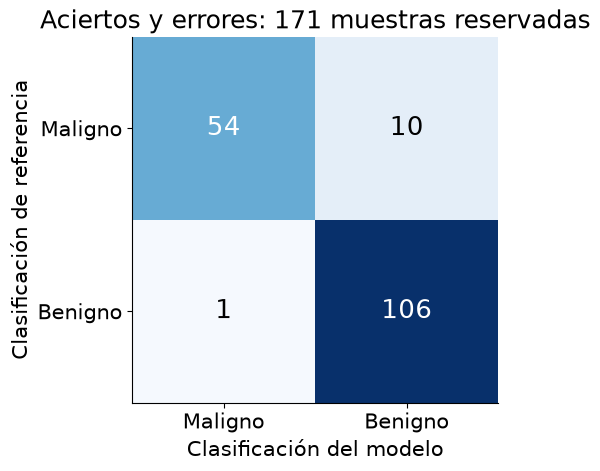

**Lee primero la fila Maligno:** 54 identificadas y 10 clasificadas como benignas. Estos 10 errores son falsos negativos; no son muestras benignas.

In [6]:
#@title B03: obtener las salidas
B03()

👀 **Dónde mirar e interpretar.** Las filas son la referencia y las columnas la predicción. Empieza por la fila Maligno: suma sus dos celdas. Después lee la fila Benigno. El color ayuda, pero los números y las etiquetas permiten leer la tabla sin distinguir colores.

📝 **Tu respuesta.** Describe con una frase el número de falsos negativos y el de falsos positivos, indicando a qué muestras corresponden.

**Escribe aquí:** ...

<details><summary>Orientación comentada: abrir después de responder</summary>

Un falso negativo es una muestra maligna clasificada como benigna. Un falso positivo es una muestra benigna clasificada como maligna. Las consecuencias clínicas serían distintas y no se deducen solo de la exactitud.

</details>

## B04. Explicar las métricas con sus denominadores

**PDF alternativo: apartados 2.3.**

Sensibilidad pregunta qué fracción de las malignas se identifica. Especificidad pregunta qué fracción de las benignas se reconoce. VPP pregunta qué fracción de las predicciones malignas lo es realmente; VPN hace lo mismo para las benignas. Exactitud reúne todos los aciertos. Los valores predictivos dependen de la composición de la población.

🎯 **Antes de ejecutar:** ¿Tienen el mismo denominador sensibilidad y VPP? Identifícalo antes de ejecutar.

▶ **Ejecutar:** pulsa el triángulo de la siguiente celda. No necesitas modificarla.

,Medida,Numerador,Denominador,Porcentaje,IC95 inferior (%),IC95 superior (%)
0,Sensibilidad,54,64,84.375000,73.571938,91.285158
1,Especificidad,106,107,99.065421,94.895064,99.834833
2,VPP,54,55,98.181818,90.394224,99.678322
3,VPN,106,116,91.379310,84.855769,95.250065
4,Exactitud,160,171,93.567251,88.849638,96.370424


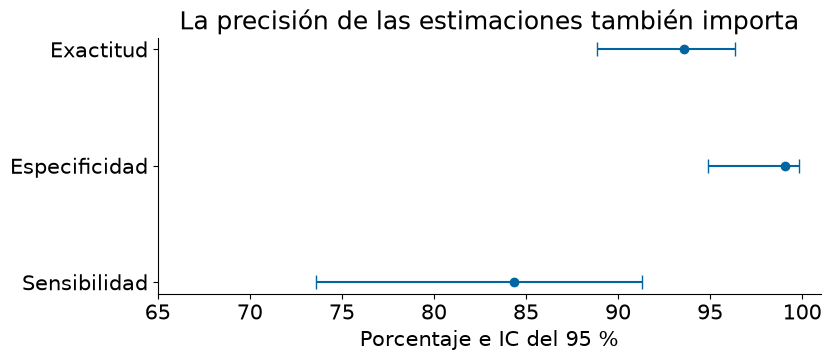

In [7]:
#@title B04: obtener las salidas
B04()

👀 **Dónde mirar e interpretar.** Lee numerador y denominador antes del porcentaje. Los IC95 de Wilson muestran incertidumbre muestral condicionada al modelo y al supuesto de observaciones independientes y representativas. No incluyen todas las diferencias entre hospitales ni la variación de entrenar otra regla. En la figura, un intervalo más ancho significa menor precisión.

📝 **Tu respuesta.** Redacta la sensibilidad como “identificó ... de ... muestras malignas”, añade su IC y explica por qué la exactitud por sí sola puede ocultar errores relevantes.

**Escribe aquí:** ...

<details><summary>Orientación comentada: abrir después de responder</summary>

La sensibilidad usa todas las malignas; el VPP, todas las predicciones malignas. El IC no contiene al 95 % de los pacientes y no demuestra que el mismo rendimiento se mantenga en otro hospital.

</details>

## B05. Distinguir discriminación, calibración y utilidad

**PDF alternativo: apartados 2.4.**

La ROC reúne diferentes umbrales. Al bajar el umbral para llamar maligna a una muestra, se clasifican más como malignas: pueden recuperarse casos, pero también aumentar falsos positivos. El punto principal sigue fijado en 0,5. No utilizamos esta figura para elegir retrospectivamente un umbral favorable.

🎯 **Antes de ejecutar:** ¿Una AUC alta impide que haya falsos negativos con el umbral 0,5?

▶ **Ejecutar:** pulsa el triángulo de la siguiente celda. No necesitas modificarla.

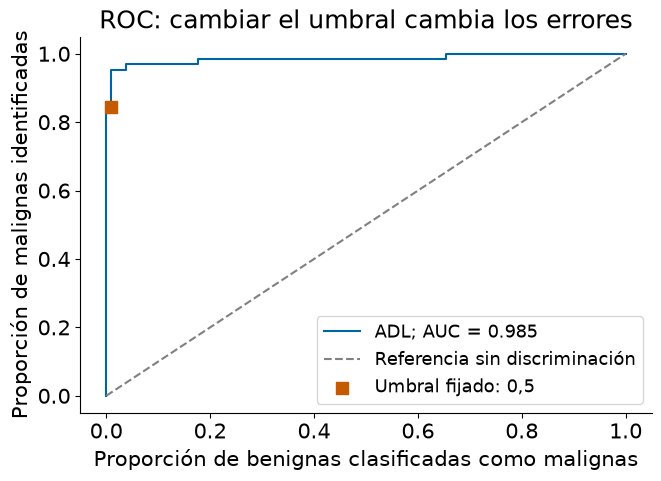

,Intervalo,n,Probabilidad media,Fracción maligna
0,0.0-0.2,111,0.012857,0.045045
1,0.2-0.4,4,0.298028,1.000000
2,0.4-0.6,2,0.478452,1.000000
3,0.6-0.8,1,0.663261,0.000000
4,0.8-1.0,53,0.993528,1.000000


**AUC y probabilidad no son equivalentes.** La tabla de probabilidades es exploratoria: un intervalo con pocas muestras informa poco. No reajustamos el modelo ni elegimos umbrales mirando este test.

In [8]:
#@title B05: obtener las salidas
B05()

👀 **Dónde mirar e interpretar.** El eje horizontal muestra benignas clasificadas como malignas; el vertical, malignas identificadas. El cuadrado señala el umbral fijado. La tabla exploratoria de calibración compara probabilidad media con fracción maligna: mira también n; las celdas pequeñas son inestables.

📝 **Tu respuesta.** Explica por qué una AUC alta no demuestra probabilidades exactas ni que usar el modelo mejore la atención.

**Escribe aquí:** ...

<details><summary>Orientación comentada: abrir después de responder</summary>

AUC resume ordenación de muestras a través de umbrales. Calibración estudia correspondencia entre probabilidades y frecuencias. Utilidad necesita valorar decisiones, consecuencias y contexto. Este cuaderno no prueba beneficio asistencial.

</details>

## B06. Comparar configuraciones sin usar el test para elegir

**PDF alternativo: apartados 5.1 a 5.4.**

La comparación se fija de antemano: siete configuraciones, cinco partes dentro del entrenamiento y exactitud equilibrada como criterio. En un problema binario esa medida es la media de sensibilidad y especificidad. Da igual peso a los dos grupos; no asigna costes clínicos. Aunque este bloque se ejecute después de mostrar el modelo base, solo usa entrenamiento para elegir.

🎯 **Antes de ejecutar:** ¿Debe conservarse un resultado sin mejora, o habría que cambiar la semilla hasta obtener una?

▶ **Ejecutar:** pulsa el triángulo de la siguiente celda. No necesitas modificarla.

In [9]:
#@title B06: obtener las salidas
B06()

,Configuración,Media CV (%),DE entre partes (%)
0,Base SVD,95.075862,3.237714
1,Regularización auto,94.397701,3.239484
2,Regularización 0.1,94.731034,2.107064
3,Regularización 0.3,94.386207,1.913033
4,Regularización 0.5,94.386207,1.913033
5,Regularización 0.7,93.896552,2.991025
6,Regularización 0.9,93.441379,2.166459


,Procedimiento,Aciertos,Muestras,Exactitud (%)
0,Base fijada,160,171,93.567251
1,Elegida dentro del entrenamiento,160,171,93.567251


**Resultado calculado:** diferencia de exactitud = +0.00 puntos porcentuales. Se conserva la partición y el criterio aunque no haya mejora.

👀 **Dónde mirar e interpretar.** La primera tabla muestra resultados internos de entrenamiento. La DE entre partes describe variación, no es un IC. Después se evalúa la configuración elegida en el test predefinido. Esa evaluación final no retroalimenta la elección.

📝 **Tu respuesta.** Anota si hubo mejora y explica qué está permitido concluir. ¿Por qué una configuración más compleja puede no ser necesaria?

**Escribe aquí:** ...

<details><summary>Orientación comentada: abrir después de responder</summary>

Una búsqueda sin mejora es informativa. No se deben cambiar datos, semilla ni criterio por desagrado con el resultado. Una diferencia observada tampoco demuestra superioridad general sin considerar incertidumbre y validación.

</details>

## B07. Conocer los datos y sus condiciones

**PDF alternativo: apartados 4.1 a 4.4.**

Exploramos solo el entrenamiento. La media resume un grupo y la DE describe dispersión. Dos variables relacionadas, como radio y perímetro, pueden aportar información redundante. Estandarizar cambia la escala; no elimina esa relación. Las condiciones de ADL se examinan dentro de cada grupo, no mezclando malignas y benignas.

🎯 **Antes de ejecutar:** ¿Un gráfico de todas las muestras mezcladas comprobaría la normalidad de cada grupo?

▶ **Ejecutar:** pulsa el triángulo de la siguiente celda. No necesitas modificarla.

,Grupo,Variable,n,Media,DE
0,Maligno,Radio medio,148,17.447770,3.102582
1,Maligno,Textura media,148,21.647365,4.069388
2,Benigno,Radio medio,250,12.108324,1.757202
3,Benigno,Textura media,250,17.976480,4.181542


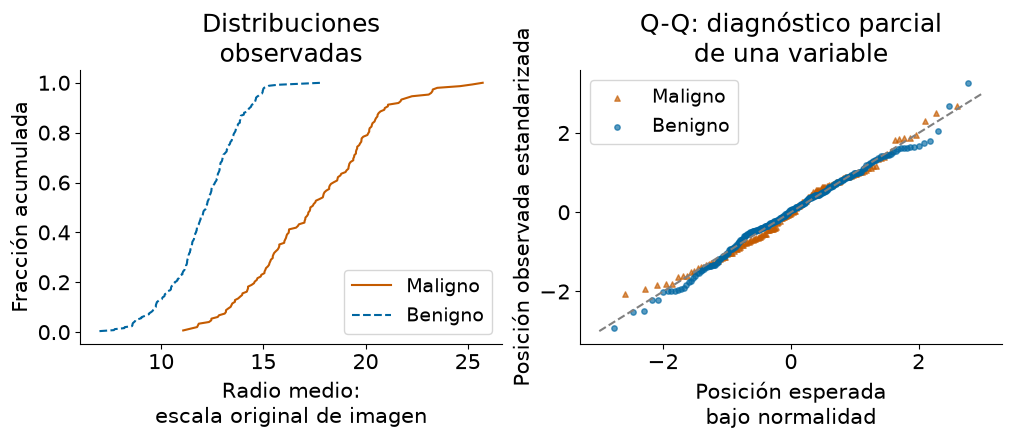

,Variables,Correlación
0,Radio y perímetro medios,0.997803


In [10]:
#@title B07: obtener las salidas
B07()

👀 **Dónde mirar e interpretar.** En la curva acumulada, la altura es la fracción de muestras hasta ese valor de radio. En Q-Q, seguir aproximadamente la diagonal es compatible con normalidad univariante; separarse invita a investigar. Un solo gráfico no demuestra normalidad multivariante. Correlación alta no demuestra causalidad.

📝 **Tu respuesta.** Señala una condición que dependa del diseño, una que puedas explorar gráficamente y un motivo para no interpretar los coeficientes como causas.

**Escribe aquí:** ...

<details><summary>Orientación comentada: abrir después de responder</summary>

La independencia depende de quién se midió y cuántas veces. Los valores extremos y la forma de las distribuciones se exploran. La covarianza común incluye cómo varían juntas las medidas. Las asociaciones de un modelo no prueban mecanismos causales.

</details>

## B08. Un segundo caso: tres grupos hospitalarios simulados

**PDF alternativo: apartados 6.1.**

Creamos 90 ingresos ficticios, 30 por diagnóstico principal: neumonía, insuficiencia cardiaca y exacerbación de EPOC. Cada ingreso representa una persona distinta. Las seis medidas son iniciales; SpO2 en aire ambiente es solo una condición del generador, nunca una instrucción para retirar oxígeno. Las etiquetas las asigna la simulación. No se representan diagnósticos coexistentes, evolución, tratamientos ni la complejidad de una urgencia real.

🎯 **Antes de ejecutar:** ¿Podríamos presentar las diferencias creadas por el generador como evidencia clínica publicada?

▶ **Ejecutar:** pulsa el triángulo de la siguiente celda. No necesitas modificarla.

In [11]:
#@title B08: obtener las salidas
B08()

,Ingreso ficticio,FR (resp/min),FC (lat/min),Temperatura (°C),SpO2 (%),Hb (g/dL),Leucocitos (10^9/L),Grupo
0,1,22.401040,100.765480,37.946230,92.783257,11.904655,14.077507,Neumonía
1,2,24.249998,109.967348,37.414162,91.839105,14.102812,10.932187,Neumonía
2,3,20.133548,117.356484,38.597943,94.682115,13.902870,15.068211,Neumonía
3,4,20.284031,94.436563,37.165233,95.141477,13.926760,14.219226,Neumonía
4,5,15.269243,82.021976,38.533020,93.899876,13.749635,14.410697,Neumonía
5,6,21.703005,109.380968,36.810707,94.151574,12.954831,14.044114,Neumonía


,Grupo,FR (resp/min),FC (lat/min),Temperatura (°C),SpO2 (%),Hb (g/dL),Leucocitos (10^9/L)
0,EPOC,25.150844,97.692864,36.915199,91.173636,14.056156,9.894781
1,Insuf. cardiaca,25.029524,99.617367,36.639562,92.247886,12.188269,8.816131
2,Neumonía,23.734261,103.312874,37.955321,92.811575,13.193619,12.669146


**SIMULACIÓN DOCENTE.** Los grupos y sus diferencias han sido creados para explicar el método. No demuestra que estas seis variables permitan diagnosticar la causa de una disnea. No se ha entrenado una herramienta asistencial.

👀 **Dónde mirar e interpretar.** Los nombres de columnas incluyen unidades. Las primeras filas son individuos ficticios; la segunda tabla resume grupos. Las medias, dispersión y correlaciones poblacionales se fijan antes de generar datos. Se usa covarianza común y semilla 20261003 sin buscar un resultado conveniente. No se han cambiado etiquetas de Iris.

📝 **Tu respuesta.** Escribe dos diferencias entre esta simulación y el conjunto real de Wisconsin. Indica qué conclusiones clínicas no permite obtener.

**Escribe aquí:** ...

<details><summary>Orientación comentada: abrir después de responder</summary>

Aquí conocemos el mecanismo generador y hemos introducido diferencias entre grupos. No hay pacientes reales ni referencia diagnóstica adjudicada de verdad. No demuestra utilidad de estas variables para diagnosticar disnea.

</details>

## B09. Comprender dos ejes, centroides y elipses

**PDF alternativo: apartados 3.1 a 3.4 y 6.2 a 6.4.**

Con tres grupos hay como máximo dos ejes discriminantes. Son combinaciones de las seis variables; no son medidas de gravedad. Cada punto representa un ingreso ficticio. El criterio busca separación entre grupos respecto de su variación interna. El ajuste de esta figura usa los 90 ingresos para describir la geometría.

🎯 **Antes de ejecutar:** Si un eje concentra casi todo el criterio discriminante, ¿es ese porcentaje la exactitud del modelo?

▶ **Ejecutar:** pulsa el triángulo de la siguiente celda. No necesitas modificarla.

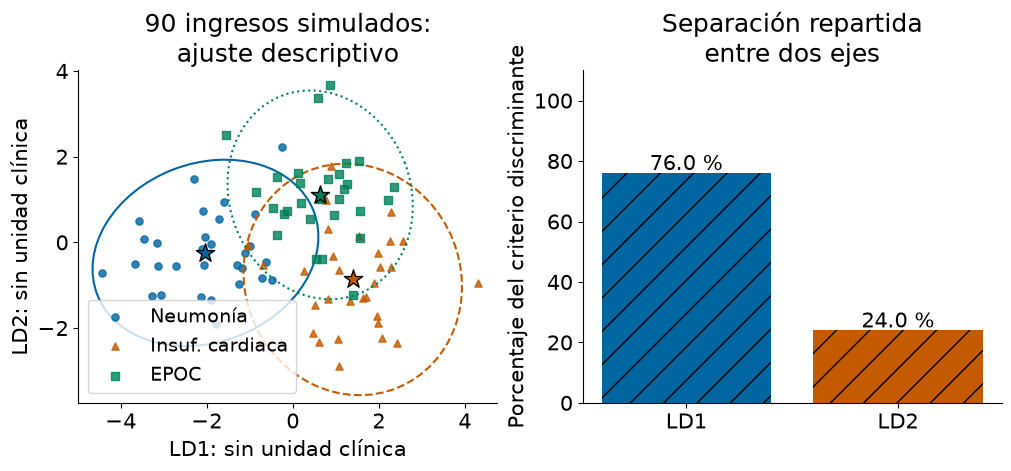

,Eje,Autovalor,Proporción (%)
0,LD1,2.230291,76.035883
1,LD2,0.702918,23.964117


,Grupo,LD1,LD2
0,Neumonía,-2.029967,-0.245436
1,Insuf. cardiaca,1.393598,-0.864222
2,EPOC,0.636369,1.109658


In [12]:
#@title B09: obtener las salidas
B09()

👀 **Dónde mirar e interpretar.** Primero localiza los símbolos de cada grupo, después el solapamiento y las estrellas (centroides). Las elipses describen dispersión gaussiana aproximada del 95 %, no seguridad diagnóstica ni IC del centroide. La barra reparte el criterio entre ejes; no cuenta pacientes acertados.

📝 **Tu respuesta.** Describe qué grupos parecen solaparse más y explica por qué necesitamos otra evaluación con observaciones reservadas.

**Escribe aquí:** ...

<details><summary>Orientación comentada: abrir después de responder</summary>

Un gráfico supervisado se construyó conociendo las etiquetas; su apariencia no estima por sí sola el error de casos nuevos. Un centroide es una posición media y no un paciente típico obligatorio. Las distancias de este espacio no son diferencias clínicas de gravedad.

</details>

## B10. Evaluar de nuevo, sin confundirlo con la figura

**PDF alternativo: apartados 6.5.**

Construimos otro ajuste, independiente del descriptivo anterior: 63 ingresos ficticios para entrenamiento y 27 para test, nueve de cada grupo. El escalado también se aprende solo con esos 63. Este ejercicio enseña separación de usos; no valida una herramienta clínica.

🎯 **Antes de ejecutar:** ¿Sería correcto reutilizar para evaluar el ajuste que ya había visto las 90 etiquetas?

▶ **Ejecutar:** pulsa el triángulo de la siguiente celda. No necesitas modificarla.

,Neumonía,Insuf. cardiaca,EPOC,Referencia
0,9,0,0,Neumonía
1,1,8,0,Insuf. cardiaca
2,2,2,5,EPOC


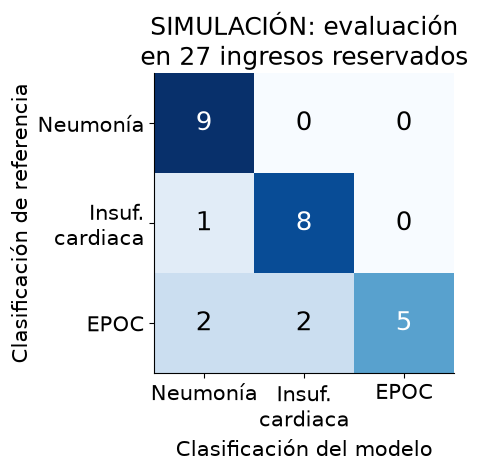

**Resultado de esta simulación:** 22 de 27 aciertos. El gráfico B09 utilizó todos los datos; esta evaluación utiliza un ajuste diferente, entrenado solo con 63 ingresos ficticios.

In [13]:
#@title B10: obtener las salidas
B10()

👀 **Dónde mirar e interpretar.** La diagonal contiene aciertos; las demás celdas muestran entre qué grupos se confunde el modelo. Lee primero una fila completa. Compara el total 27 con los 90 de la figura B09: no son el mismo ajuste.

📝 **Tu respuesta.** Informa los aciertos sobre 27 y explica por qué esos resultados no se trasladan a pacientes con disnea.

**Escribe aquí:** ...

<details><summary>Orientación comentada: abrir después de responder</summary>

Los resultados dependen de un generador didáctico y una muestra pequeña. No representan la población atendida ni incorporan diagnósticos mixtos. La evaluación enseña el procedimiento, no eficacia clínica.

</details>

## B11. 🌱 Ampliar: pesos y asociaciones

**PDF alternativo: apartados 7.1 a 7.4.**

Un coeficiente es un peso dentro de una combinación; una correlación describe asociación. En esta ampliación los pesos se expresan tras ajustar por la DE intragrupo. La estructura se calcula dentro de los grupos, evitando confundir la mezcla de grupos con esas relaciones.

🎯 **Antes de ejecutar:** ¿El coeficiente mayor identifica necesariamente la causa del diagnóstico?

▶ **Ejecutar:** pulsa el triángulo de la siguiente celda. No necesitas modificarla.

,Variable,Coef. LD1 est.,Estructura LD1
0,FR (resp/min),0.220111,0.141472
1,FC (lat/min),-0.242261,-0.130769
2,Temperatura (°C),-0.804169,-0.899003
3,SpO2 (%),-0.116622,-0.182778
4,Hb (g/dL),-0.112299,-0.126413
5,Leucocitos (10^9/L),-0.303091,-0.589651


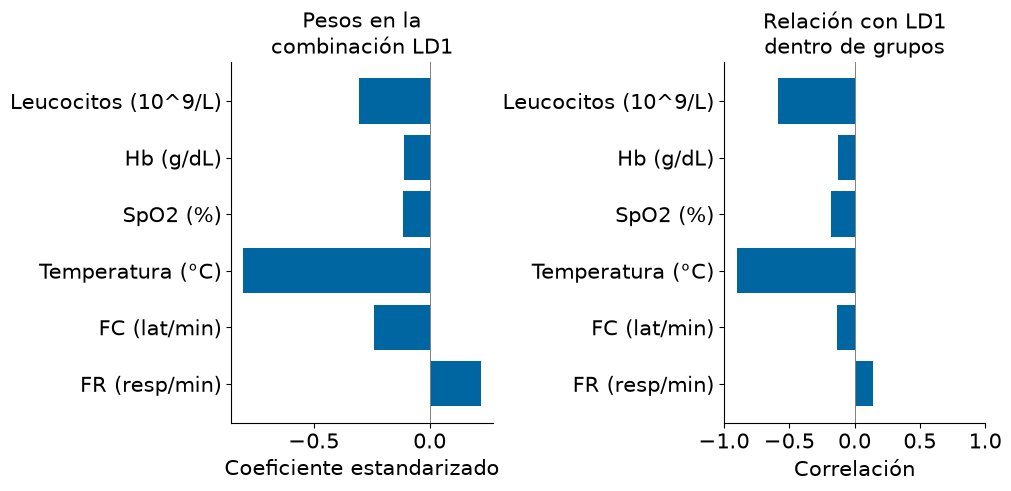

In [14]:
#@title B11: obtener las salidas
B11()

👀 **Dónde mirar e interpretar.** Compara el panel de pesos con el de correlaciones. Sus escalas y preguntas son diferentes. Invertir todo un eje lo refleja sin cambiar la separación; un LD1 positivo no es un indicador universal de gravedad.

📝 **Tu respuesta.** Explica una razón por la que el peso de una variable puede cambiar cuando se incluyen otras relacionadas.

**Escribe aquí:** ...

<details><summary>Orientación comentada: abrir después de responder</summary>

Los coeficientes dependen de unidades, normalización y correlaciones. Una medida puede compartir información con otra. No son porcentajes de importancia ni efectos causales.

</details>

## B12. 🌱 Ampliar: diferencias de medias y cálculo interno

**PDF alternativo: apartados 8.1 a 8.3.**

Usamos temperatura, una variable predefinida de la simulación. ANOVA estudia diferencias de medias entre tres grupos. Las curvas son las normales teóricas que se emplearon al generar los datos, no una distribución impuesta a pacientes reales. Las comprobaciones de matrices verifican el cálculo y pueden ejecutarse sin estudiar la fórmula.

🎯 **Antes de ejecutar:** ¿Diferentes medias implican que la temperatura permita clasificar sin errores a cada ingreso?

▶ **Ejecutar:** pulsa el triángulo de la siguiente celda. No necesitas modificarla.

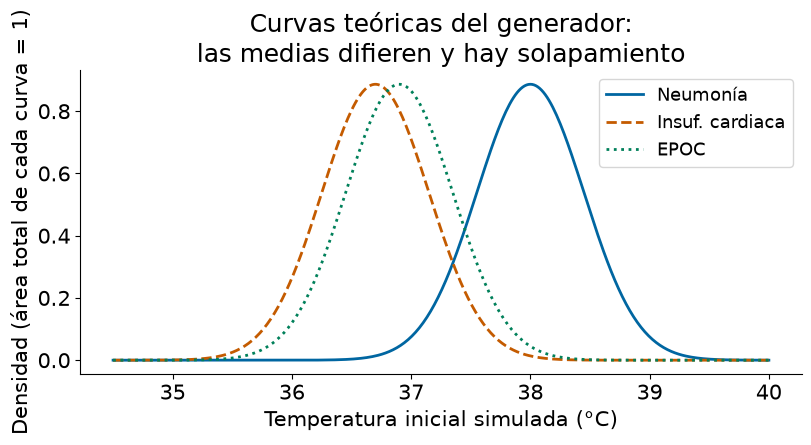

,Variable,F,p,n
0,Temperatura (°C),78.421974,3.386229e-20,90


,Comprobación,Resultado
0,Dispersión total = dentro + entre,Correcta
1,Proyección coherente,Correcta
2,Normalización intragrupo,Correcta
3,Proporciones por autovalores,Correcta


In [15]:
#@title B12: obtener las salidas
B12()

👀 **Dónde mirar e interpretar.** Observa el área de solapamiento. La tabla F/p corresponde al ANOVA exploratorio de temperatura. No usamos ese p-valor para elegir variables. La tabla final confirma cuatro identidades numéricas; no mide utilidad clínica.

📝 **Tu respuesta.** Distingue la pregunta del ANOVA de la pregunta de una tabla de errores en test.

**Escribe aquí:** ...

<details><summary>Orientación comentada: abrir después de responder</summary>

ANOVA compara medias poblacionales bajo sus condiciones. La matriz de confusión cuenta clasificaciones individuales. Puede haber diferencias claras de medias junto a considerable solapamiento.

</details>

## B13. 🌱 Ampliar: qué pregunta responde Wilks

**PDF alternativo: apartados 8.4.**

Lambda de Wilks compara dispersión dentro de grupos con dispersión total. Permutamos las etiquetas 1999 veces conservando tamaños para ilustrar un contraste global. El intercambio requiere condiciones: bajo normalidad y covarianza común, igualdad de medias implica igualdad de distribuciones. No basta asumir solo medias iguales cuando las covarianzas son distintas.

🎯 **Antes de ejecutar:** Si ninguna permutación resulta tan extrema como la observada, ¿el p-valor es cero?

▶ **Ejecutar:** pulsa el triángulo de la siguiente celda. No necesitas modificarla.

In [16]:
#@title B13: obtener las salidas
B13()

,Lambda,Permutaciones,Extremos,p Monte Carlo
0,0.181788,1999,0,0.0005


👀 **Dónde mirar e interpretar.** Lee Lambda y p Monte Carlo por separado. Se aplica (extremos+1)/(1999+1), así que el mínimo resoluble es 0,0005. Este p-valor no es exactitud, ni probabilidad de que el modelo sea correcto.

📝 **Tu respuesta.** Explica por qué el contraste global no sustituye al bloque B10.

**Escribe aquí:** ...

<details><summary>Orientación comentada: abrir después de responder</summary>

Wilks pregunta por separación global y la permutación contrasta bajo intercambiabilidad. B10 evalúa predicciones en observaciones reservadas. La permutación tiene resolución finita: cero extremos no significa probabilidad cero.

</details>

## B14. Leer una publicación real

**PDF alternativo: 9.2.** Wolberg WH, Street WN y Mangasarian OL (1994). *Machine learning techniques to diagnose breast cancer from image-processed nuclear features of fine needle aspirates*. Cancer Letters 77:163-171. [Resumen en PubMed](https://pubmed.ncbi.nlm.nih.gov/8168063/). [DOI](https://doi.org/10.1016/0304-3835(94)90099-X).

Consultamos **el resumen**, no el protocolo completo. Describe desarrollo con 569 pacientes y evaluación en 54 pacientes nuevos. La población procede de aspirados mamarios; el resultado de interés es la clasificación diagnóstica. No se reproducen figuras del artículo ni se usan sus 54 observaciones como nuestro test. Nuestro ADL y partición no reconstruyen el sistema del artículo.

🎯 **Pregunta:** ¿por qué evaluar pacientes nuevos aporta información distinta de evaluar los usados para construir el sistema?

📝 **Tu respuesta:** ...

<details><summary>Orientación: abrir después de responder</summary>

Las observaciones nuevas permiten examinar generalización fuera de las usadas para desarrollar el sistema. Su tamaño, selección y semejanza con la población objetivo siguen importando. El resumen no basta para auditar sesgos, verificación de etiquetas, incertidumbre ni validación externa completa. No atribuyas las cifras de nuestro cuaderno al artículo.

</details>


## B15. Tu informe clínico y ayuda opcional

**PDF alternativo: 9.1, 9.3 y 9.4.** Redacta 6-8 líneas con pregunta, fuente y unidad de observación; evento positivo; entrenamiento/test; sensibilidad con IC, especificidad y falsos negativos; y dos limitaciones. Separa la base real de la simulación.

📝 **Mi informe:** ...

**Autoevaluación:** ¿he indicado denominadores y unidades? ¿He confundido AUC con porcentaje de aciertos? ¿He atribuido utilidad clínica a una simulación? ¿He señalado qué falta para otro hospital?

💬 **Gemini, opcional.** Un prompt es una petición escrita en lenguaje natural en el chat, no código. Su estructura es contexto + tarea + información + formato. La interfaz puede variar y esta práctica se completa sin IA. Escribe primero tu interpretación y comprueba después cada cifra.

**Para comprender:** «Soy enfermera/médico y empiezo con estadística. Con esta tabla de muestras benignas y malignas [pegar tabla], explícame sensibilidad y VPP con sus denominadores. Termina con una pregunta; no inventes datos».

**Para revisar:** «Revisa mi interpretación [pegar texto] usando solo esta tabla y la definición de malignidad como evento [pegar]. Señala errores de unidades, incertidumbre o causalidad. No cambies el análisis. Termina con una pregunta que me ayude a razonar».

**Para ampliar:** «Sobre otra copia del cuaderno, propón una actividad para comprender calibración. Conserva datos, semilla, partición y análisis principal; justifica cualquier cambio y sepáralo como ampliación. No busques significación ni un resultado favorable».

No introduzcas datos identificables o confidenciales de pacientes. Gemini no valida por sí mismo el análisis. No necesitas ejecutar cambios de código para completar esta práctica.


## B16. Guardar los recursos y comprobar la correspondencia

**PDF alternativo: 9.4.** Ejecuta este bloque después de los anteriores, incluidas las celdas de ampliación. Comprueba coherencia de recuentos y genera tablas CSV/LaTeX, figuras PDF/PNG, datos y un manifiesto. Son los recursos que alimentan el manual de esta versión.

▶ Ejecuta. En Colab abre el panel **Archivos**, localiza **recursos_adl_v1.zip**, usa su menú y selecciona **Descargar**. Si solo quieres entregar la práctica, descarga además el notebook con tus respuestas desde Archivo. No necesitas abrir Python ni compilar el PDF.


In [17]:
#@title B16: verificar y guardar
B16()

**Práctica completada.** Tablas, figuras, datos y cifras del manual están guardados en recursos_adl_v1.zip. En Colab, abre el panel Archivos y descarga ese ZIP si lo necesitas. Guarda también tu copia del notebook con tus respuestas.

### Fuentes y uso de los datos

- Wisconsin: Wolberg y colaboradores, UCI. DOI [10.24432/C5DW2B](https://doi.org/10.24432/C5DW2B), licencia **CC BY 4.0** según UCI. Copia suministrada por [scikit-learn](https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset). Sin exclusiones ni imputaciones; 30 características; las unidades físicas no documentadas se identifican como escala de imagen.
- [ADL: documentación del método](https://scikit-learn.org/stable/modules/lda_qda.html).
- [Preprocesamiento y prevención de filtración de información](https://scikit-learn.org/stable/common_pitfalls.html).
- La simulación se crea dentro del cuaderno con reglas declaradas en B08; no deriva de Iris ni de pacientes reales.

La versión de los paquetes, las huellas de datos y las semillas quedan registradas en el manifiesto. La comprobación local y la situación de prueba en Colab constan en el informe de entrega; no se presume una prueba remota por el mero hecho de que exista este cuaderno.
